# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of conca


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

final_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for model_name, model in base_models.items():
    scores = cross_val_score(model,X_train, y_train, scoring='f1_macro', cv=5, verbose=3, n_jobs=-1)
    baseline_results[model_name] = (scores.mean(), scores.std())


# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    model.fit(X_train, y_train)
    test_f1 = f1_score(y_test, model.predict(X_test))
    final_results[name] = [f"{mean:.4f} ± {std:.4f}", test_f1]
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[CV] END ................................ score: (test=0.988) total time=   0.0s
[CV] END ................................ score: (test=0.954) total time=   0.0s
[CV] END ................................ score: (test=0.940) total time=   0.0s
[CV] END ................................ score: (test=0.977) total time=   0.0s
[CV] END ................................ score: (test=0.988) total time=   0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[CV] END ................................ score: (test=0.988) total time=   0.1s
[CV] END ................................ score: (test=0.965) total time=   0.1s
[CV] END ................................ score: (test=0.916) total time=   0.1s
[CV] END ................................ score: (test=0.930) total time=   0.1s
[CV] END ................................ score:

## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': np.logspace(-1, 2, 4),
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf','linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")



Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=rbf;, score=0.929 total time=   0.0s
[CV 2/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=rbf;, score=0.977 total time=   0.0s
[CV 3/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=rbf;, score=0.939 total time=   0.0s
[CV 4/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=rbf;, score=0.916 total time=   0.0s
[CV 2/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=linear;, score=0.988 total time=   0.0s
[CV 3/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=linear;, score=0.952 total time=   0.0s
[CV 5/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=rbf;, score=0.941 total time=   0.0s
[CV 4/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=linear;, score=0.988 total time=   0.0s
[CV 1/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=linear;, score=0.965 total time=   0.0s
[CV 5/5] END svm__C=0.1, svm__gamma=scale, svm__kernel=linear;, score=0.988 total time=   0.0s
[CV

In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

svm_results = pd.DataFrame(svm_grid_search.cv_results_)
svm_results = svm_results[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
top_10 = svm_results.sort_values(by='rank_test_score').head(10)
print(top_10)

best_index = svm_grid_search.best_index_
mean = svm_grid_search.cv_results_['mean_test_score'][best_index]
std = svm_grid_search.cv_results_['std_test_score'][best_index]
final_results['SVM Grid Search'] = [f"{mean:.4f} ± {std:.4f}", f1_score(y_test, svm_grid_search.best_estimator_.predict(X_test))]

# YOUR CODE HERE

                                               params  mean_test_score  \
14  {'svm__C': 10.0, 'svm__gamma': 0.01, 'svm__ker...         0.978633   
1   {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...         0.976215   
3   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...         0.976215   
5   {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...         0.976215   
22  {'svm__C': 100.0, 'svm__gamma': 0.001, 'svm__k...         0.976157   
16  {'svm__C': 10.0, 'svm__gamma': 0.001, 'svm__ke...         0.971340   
6   {'svm__C': 1.0, 'svm__gamma': 'scale', 'svm__k...         0.969357   
12  {'svm__C': 10.0, 'svm__gamma': 'scale', 'svm__...         0.969350   
20  {'svm__C': 100.0, 'svm__gamma': 0.01, 'svm__ke...         0.966936   
8   {'svm__C': 1.0, 'svm__gamma': 0.01, 'svm__kern...         0.966732   

    std_test_score  rank_test_score  
14        0.017581                1  
1         0.015266                2  
3         0.015266                2  
5         0.015266               

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),
    'max_depth': [randint(2, 20), None],
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]

}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=3
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

best_index = rf_random_search.best_index_
mean = rf_random_search.cv_results_['mean_test_score'][best_index]
std = rf_random_search.cv_results_['std_test_score'][best_index]
final_results['RF Random Search'] = [f"{mean:.4f} ± {std:.4f}", f1_score(y_test, rf_random_search.best_estimator_.predict(X_test))]


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END max_depth=<scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa848760350>, max_features=sqrt, min_samples_split=16, n_estimators=156;, score=nan total time=   0.0s
[CV 2/5] END max_depth=<scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f1f965c57d0>, max_features=sqrt, min_samples_split=16, n_estimators=156;, score=nan total time=   0.0s
[CV 3/5] END max_depth=<scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa848763910>, max_features=sqrt, min_samples_split=16, n_estimators=156;, score=nan total time=   0.0s
[CV 4/5] END max_depth=<scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f1f965afe50>, max_features=sqrt, min_samples_split=16, n_estimators=156;, score=nan total time=   0.0s
[CV 5/5] END max_depth=<scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa8487b2cd0>, max_features=sqrt, min_samples_split=16, n_estimators=156;, sc

## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

df_result = pd.DataFrame.from_dict(
    final_results,
    orient='index',
    columns=['CV F1 (mean±std)', 'Test F1']
)

print(df_result)


# YOUR CODE HERE

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

                   CV F1 (mean±std)   Test F1
SVM                 0.9694 ± 0.0193  0.986111
RandomForest        0.9504 ± 0.0255  0.986111
LogisticRegression  0.9787 ± 0.0139  0.986111
SVM Grid Search     0.9786 ± 0.0176  0.986111
RF Random Search    0.9622 ± 0.0254  0.965517


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

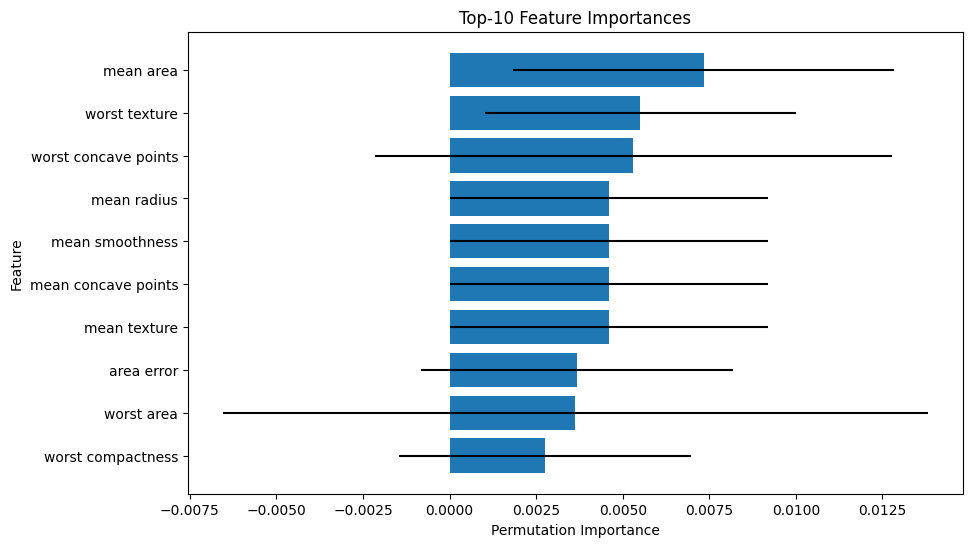

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

# Построим bar plot топ-10 признаков
# YOUR CODE HERE

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': pi_result.importances_mean,
    'importance_std': pi_result.importances_std
})

top_10_pi = importance_df.sort_values(by='importance_mean', ascending=False).head(10)
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_pi['feature'],
    top_10_pi['importance_mean'],
    xerr=top_10_pi['importance_std']
)
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Top-10 Feature Importances')


plt.gca().invert_yaxis()

plt.show()

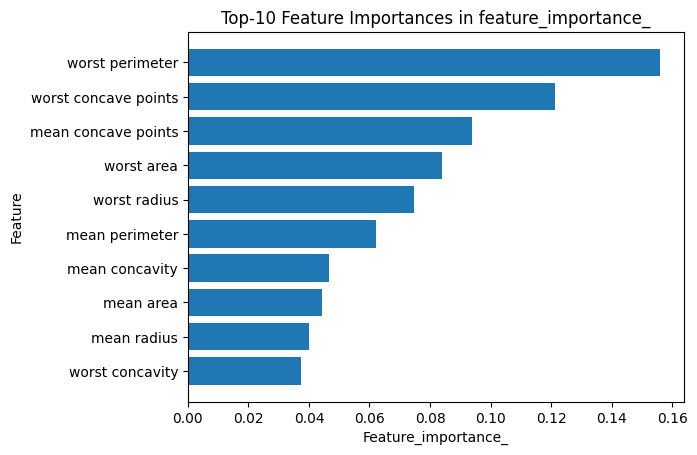

In [9]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': best_rf.feature_importances_
}).sort_values(by='importance_mean', ascending=False).head(10)

plt.barh(
    importance_df['feature'],
    importance_df['importance_mean']
)

plt.xlabel('Feature_importance_')
plt.ylabel('Feature')
plt.title('Top-10 Feature Importances in feature_importance_')
plt.gca().invert_yaxis()
plt.show()

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

Можно заметить, что действительно достаточно разные результаты. Что у одного является самым важным, у второго не входит даже в топ 5. В встроенной feature_importance_ важность распредилилась на первых местах среди коррелированных признаков (с приставкой worst). Эти признаки более менее одинаково уменьшают ошибку. Поэтому она как бы размазалась между ними. Но это делает оценку модели нечестным, так как если в этой группе важность одного признака больше другого, то нельзя считать, что он намного важнее, ведь по факту они могут быть взаимозаменяемыми. PI отвечает на другой вопрос: "насколько модель без этого признака будет сильно ошибаться". В этом случае встает другая проблема: если есть коррелированные признаки, то при удалении одного из них модель не сильно потеряет в качестве и важность занизиться, хотя без этих признаков в совокупности модель может упасть в качестве сильнее. Можно заметить, что в 1-ом графике те, кто был в топе во 2 графике, один попал в топ 1, второй попал в 5 место, а третий вообще не попал в топ 10 (но это может быть занижение). С другой стороны PI дал возможность пройти признакам уже без worst, теперь в топ 5 есть разнообразие.т Другими словами оценивает, насколько признак делает уникальный вклад. Worst perimeter, worst area, worst radius являются скоррелированными, поэтому их важность как бы занижена.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

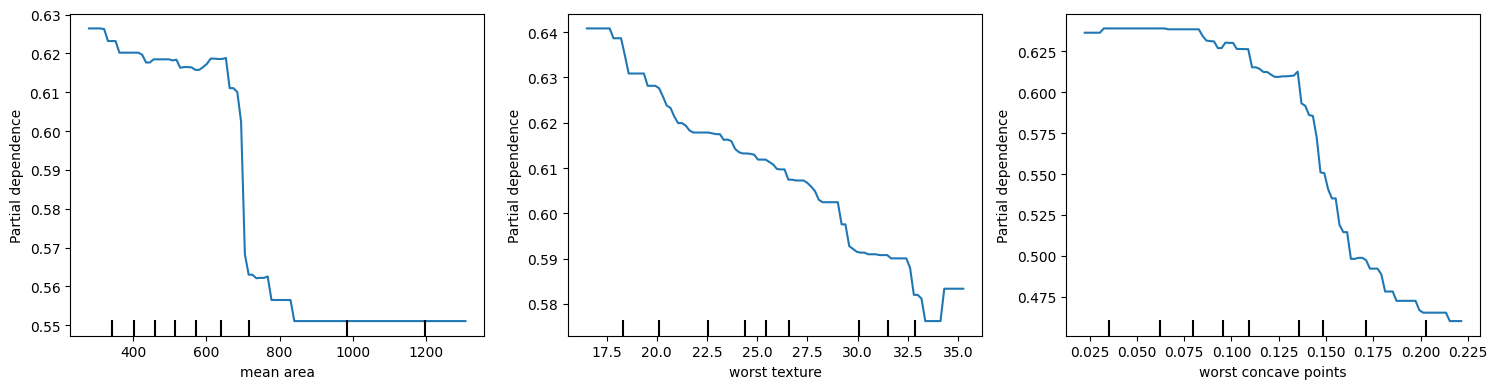

In [10]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = np.argsort(pi_result.importances_mean)[-3:][::-1]
# YOUR CODE HERE

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE

for i, idx, in enumerate(top3_idx):
    PartialDependenceDisplay.from_estimator(
        best_rf,
        X_test,
        [idx],
        kind='average',
        feature_names=X_test.columns,
        ax=ax[i]
    )

plt.tight_layout()
plt.show()

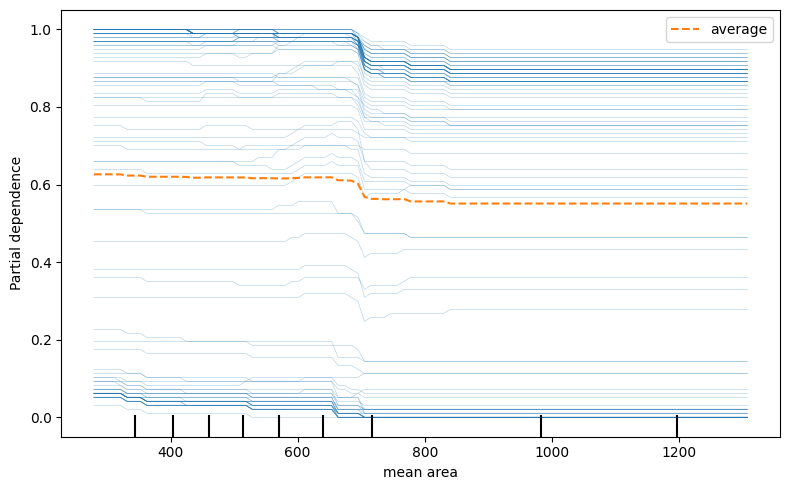

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

top1_idx = top3_idx[0]
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    [top1_idx],
    kind='both',
    feature_names=X_test.columns,
    ax=ax
)

plt.tight_layout()
plt.show()
# YOUR CODE HERE

Можно сделать вывод, что в среднем объекты ведут себя похоже на pdp линию. Хоть есть какие-то разные поведения (как например над и под линией красной объекты все-таки немного по-разному ведут, но эти отличия не существенны)

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [12]:
!pip install numpy==1.26.4
!pip install scipy==1.10.1
!pip install scikit-learn==1.3.2
!pip install shap==0.43.0


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 56.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:
      Successfully uninstalled scipy-1.11.4

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.9/532.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 49.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [13]:

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print(f'Форма shap_values: {np.array(shap_values).shape}')

Форма shap_values: (2, 114, 30)


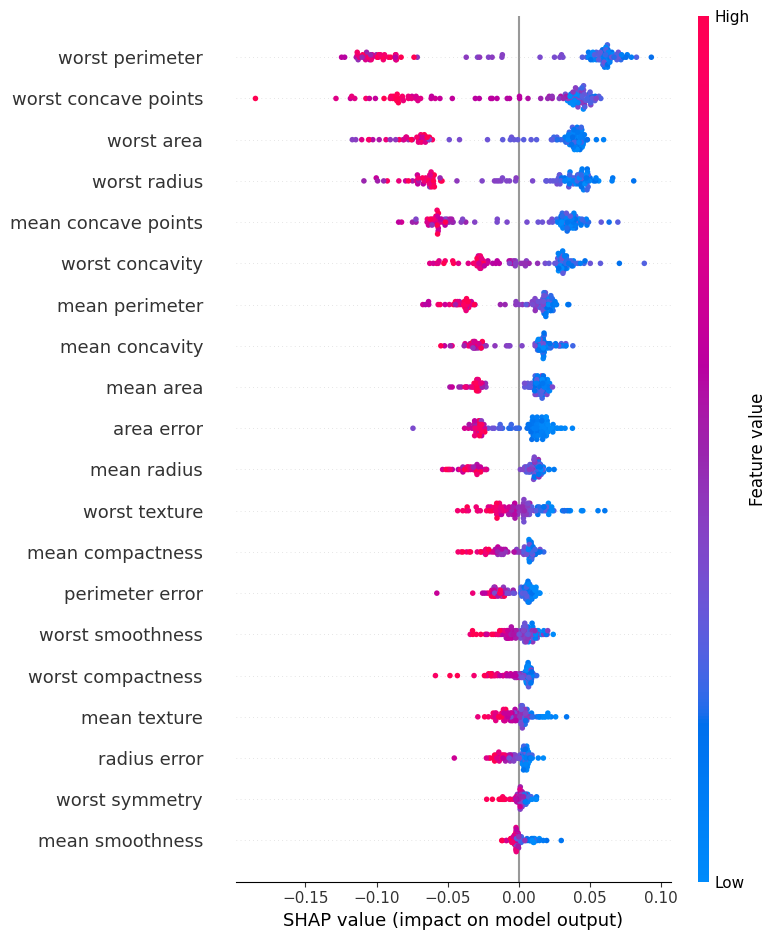

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap.summary_plot(
    shap_values[1],
    X_test
)

Можно заметить, что в топ 5 признаки больше всего совпадают с встроенным feature_importance_ нежели с PI. Worst concavity points стабильно занимает топ места в рейтингах, также и worst radius. SHAP отвечает на вопрос: "Как значения признака влияет на предсказания данного объекта?". Можно видеть, что для больших значений больше толкается в сторону злокачественной опухоли, в то время как маленькие стабильно толкают в сторону доброкачественной.

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
# SHAP values
err = errors[0]
shap_values = explainer.shap_values(X_test)

# Для бинарной классификации обычно берут класс 1
class_id = 1
contrib = pd.Series(shap_values[class_id][err], index=X_test.columns)
contrib = contrib.sort_values()
print("\nТянули к классу 0 (malignant) — виновники ошибки:")
print(contrib.head(5).to_string())
print("\nТянули к классу 1 (benign) — за правильный ответ:")
print(contrib.tail(5).to_string())

shap.force_plot(
    explainer.expected_value[class_id],
    shap_values[class_id][err],
    X_test.iloc[err]
)

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0

Тянули к классу 0 (malignant) — виновники ошибки:
worst area        -0.114601
worst perimeter   -0.106200
worst radius      -0.099238
mean perimeter    -0.063262
mean area         -0.048380

Тянули к классу 1 (benign) — за правильный ответ:
mean symmetry           0.006929
radius error            0.007245
mean concavity          0.017901
worst concave points    0.032812
worst concavity         0.088310


Можно видеть, что эти фичи, которые тянули к классу malignant, были в топах по важности призаков. При этом worst concave points, который уже показал себя достаточно надежно в этих топах  достаточно сильно тянул к правильному классу. Но это не хватило из-за троицы упомянутой ранее: worst area, worst radius, worst perimeter. У них вклад один и тот же почти один и тот же (как мы знаем, что если признаки делают один и тот же вклад, то их shap value будет совпадать), что очень сильно намекает на коррелированность. Я бы удалила некоторые скоррелированные признаки, чтобы разговор про размер не утраивался так сказать из-за наличия нескольких коррелированных признаков.

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [16]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

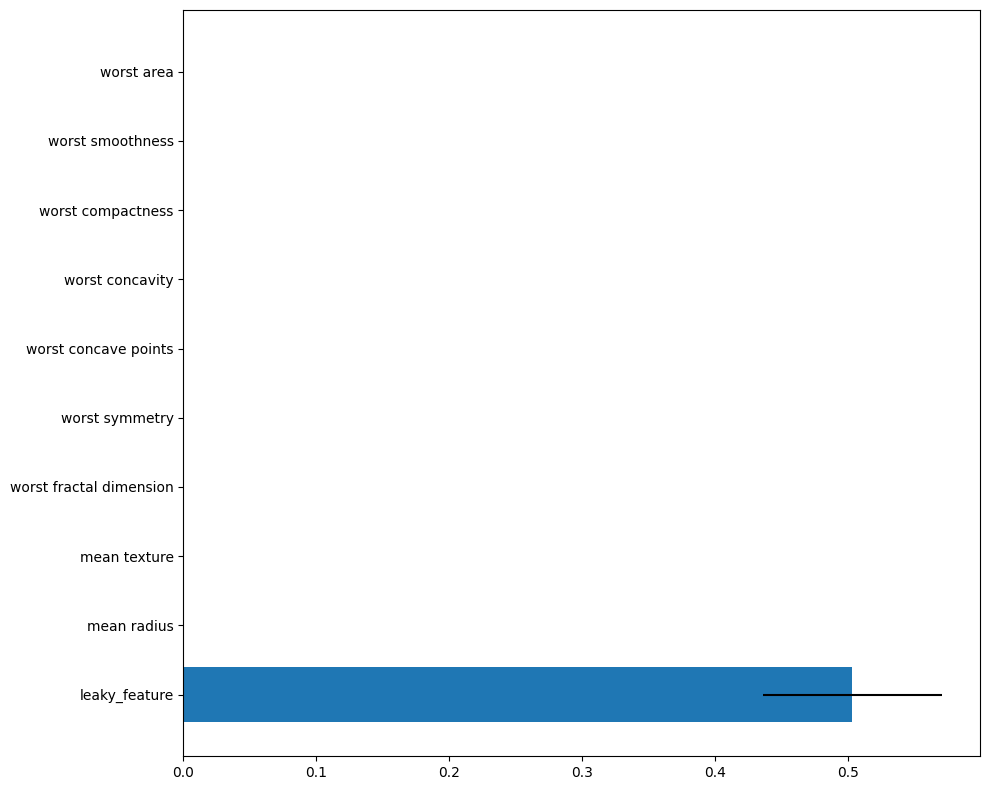

In [17]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

rf_ext = RandomForestClassifier(max_features=0.5, min_samples_split=4, n_estimators=338)
rf_ext.fit(X_train_ext, y_train)
pi_result = permutation_importance(
    rf_ext,
    X_test_ext,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

importance_df = pd.DataFrame({
    'feature': X_test_ext.columns,
    'importance_mean': pi_result.importances_mean,
    'importance_std': pi_result.importances_std
})
top_10_ext = importance_df.sort_values(by='importance_mean', ascending=False).head(10)
plt.figure(figsize=(10, 8))
plt.barh(
    top_10_ext['feature'],
    top_10_ext['importance_mean'],
    xerr=top_10_ext['importance_std']
)

plt.tight_layout()
plt.show()

Можно заметить, что все фичи, кроме leaky_feature, стали нулевые. Это красноречиво говорит о том, что есть некая утечка, что модель, теряя этот признак, теряет в преимуществе очень сильно.

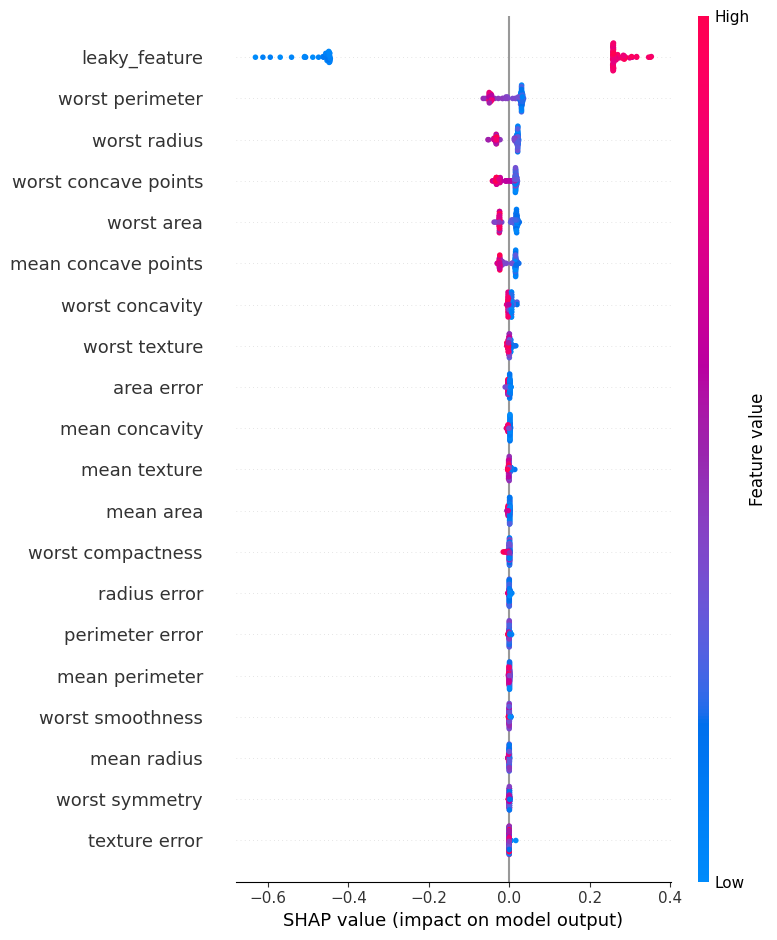

In [18]:
explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)
shap.summary_plot(
    shap_values_ext[1],
    X_test_ext
)

По Shap заметно, что все фичи, кроме нашей leaky feature, получили катастрофически мало shap value по сравнению с этой подозрительной. Хоть worst perimeter и worst concave пытались вырваться на вверх, тем не менее баллов у них кратно меньше, чем у leaky.

Теперь выкинем leaky feature и объективно посмотрим, как ведет себя random feature

In [19]:
X_train_ext = X_train_ext.drop(['leaky_feature'], axis=1)
X_test_ext = X_test_ext.drop(['leaky_feature'], axis=1)

Смотрим на топ 10 самых худших признаков

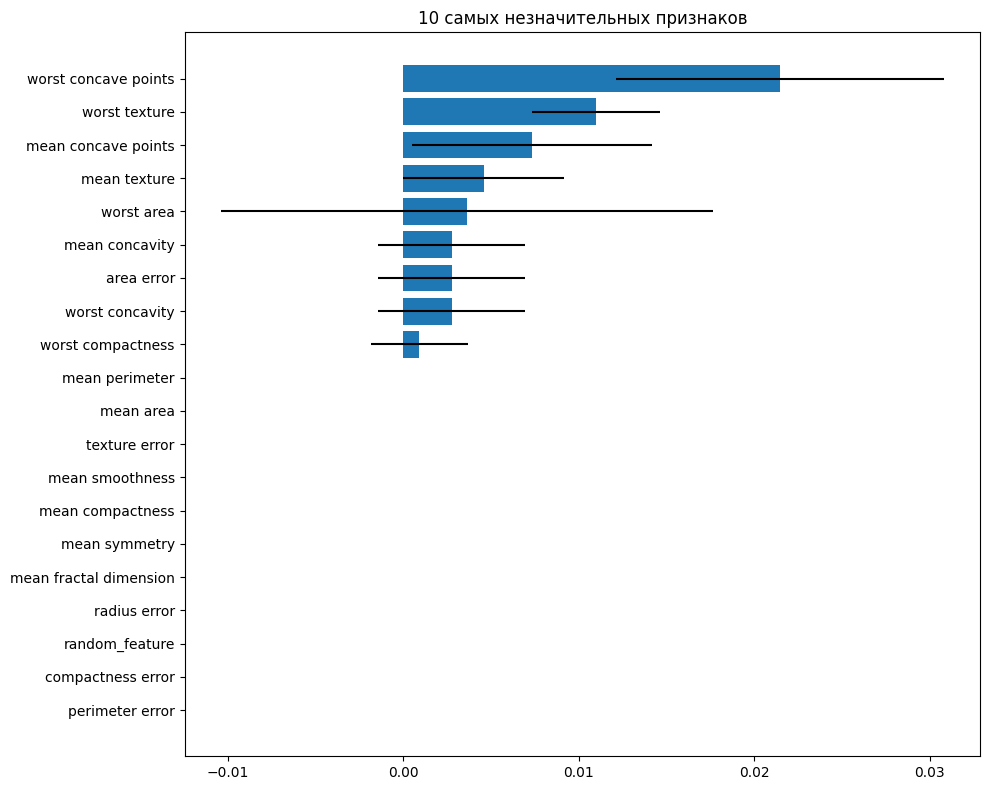

In [20]:
rf_ext = RandomForestClassifier(max_features=0.5, min_samples_split=4, n_estimators=338)
rf_ext.fit(X_train_ext, y_train)
pi_result = permutation_importance(
    rf_ext,
    X_test_ext,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

importance_df = pd.DataFrame({
    'feature': X_test_ext.columns,
    'importance_mean': pi_result.importances_mean,
    'importance_std': pi_result.importances_std
})

#Смотрим с конца
top_10_ext = importance_df.sort_values(by='importance_mean', ascending=True).tail(20)
plt.figure(figsize=(10, 8))
plt.barh(
    top_10_ext['feature'],
    top_10_ext['importance_mean'],
    xerr=top_10_ext['importance_std']
)

plt.title('10 самых незначительных признаков')
plt.tight_layout()
plt.show()

Можно заметить, что random_feature получил 0. Он в этом неединственный конечно, однако когда некоторые признаки получить могли из-за коррелированности, random_feature, как мы знаем, точно не скоррелирован.

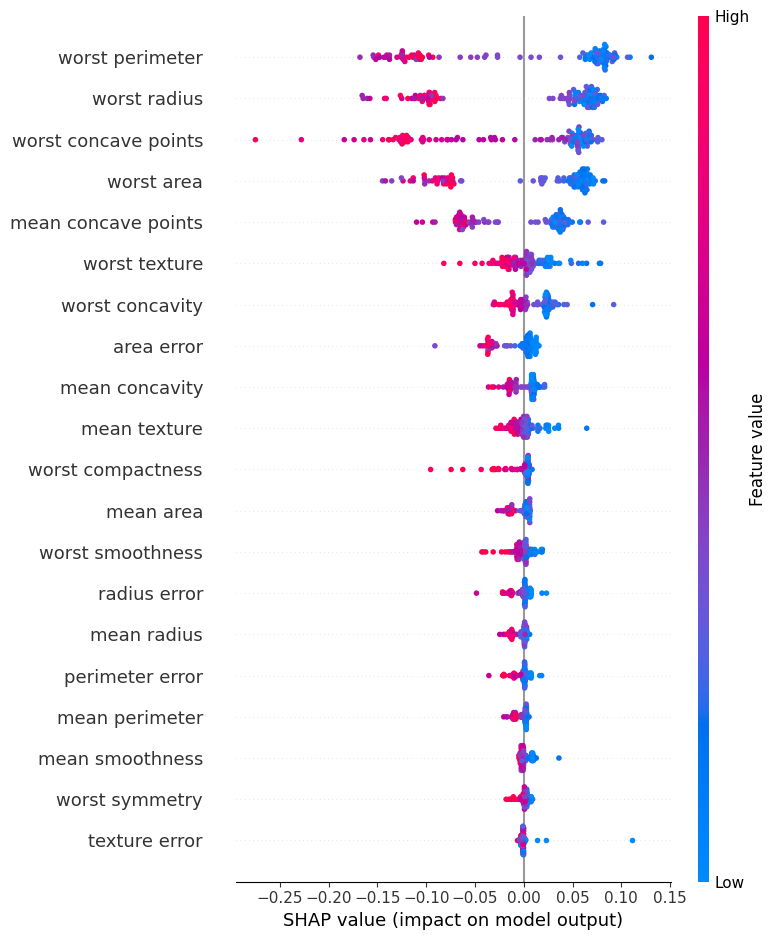

In [21]:
explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)
shap.summary_plot(
    shap_values_ext[1],
    X_test_ext
)

Можно заметить, что random feature даже не появилась в shap, что означает, что она имеет почти что нулевой вклад.

a) Как PI определяет leaky_feature?                        
Почему метрика на тесте выросла? 
- В нашем случае, PI просто обесценила другие фичи, выделив только вот эту подозрительную. А подозрительная просто имеет некоторую утечку информации, что вообще-то не совсем честно. Что если эта информация случайно появилась как протоколирование заболевания, которое ставится врачом ПОСЛЕ постановки диагноза.                    
б) Как SHAP выделяет leaky_feature в summary plot?  
- В этом случае просто у этой фичи будет ненормально большой shap баллы, намного больше, чем у остальных фичей        
в) Как обнаружить random_feature как «шумовой»?  
- Как мы можем видеть, random_feature выдает себя в PI нулем, так как удаление его не может приводить к улучшению модели, а также в shap, где она может даже не появится из-за микроскопического вклада в метрику. Это бесполезный игрок.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [22]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

Выводы по сводной таблице:
- Лучше всего показал себя из 4ех моделей показал себя SVM на CV, параметры которого найдены Grid Search.
- Модели с Search показывали себя лучше на CV, чем без него. Однако стоит отметить, что в случае Random Forest метрика на test упала именно на Search, по сравнению с обычным Random Forest. У svm после search метрика на test вообще не изменилась. Это показывает то, что Search гарантированно улучшает лишь метрики на train (CV), но на test это всегда будет некой загадкой. Тем не менее хоть переобучение снизилось.
- А самой лучшей вообще моделью, стала логистическая регрессия. Её не смогла переплюнуть ни одна модель с search. Это показывает то, что иногда старая добрая база работает лучше всего и логистическую регрессию в качестве baseline разумно брать. 

<img src="image-20260522-230616.png" width="" align="" />

1. Насколько тюнинг улучшил модели?
- Насколько это возможно, это улучшило модели, виден результат, хоть и незначительный. Однако все равно тюнинг не помог выиграть старому доброму LogisticRegression. Показывает то, что улучшение тюнинг дает в основном небольшое.
2. Совпадают ли топ-признаки по PI и SHAP?                  ║
    Если нет — почему?
- Не совпадают не совсем, потому что подходы совершенно разные. PI оценивает уникальный вклад признака в результат модели. PI будет занижать важность скоррелированных признаков (ведь при удалении одного коррелированного признака, модель будет полагаться на других). В то время как SHAP дает одно и то же баллов для признаков, которые делают одинаковый вклад в результат. Поэтому скоррелированные признаки получают почти одно и то же количество баллов.


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [23]:
!pip install optuna==4.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [24]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state': 42,
        'n_jobs': -1
    }
    #max_depth есть параметр None. Поэтому приходится вот так выкручиваться
    use_none = trial.suggest_categorical('use_none', [True, False])
    if use_none:
        params['max_depth'] = None
    else:
        params['max_depth'] = trial.suggest_int('max_depth', 2, 20)

    model = RandomForestClassifier(**params)
    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=3
    ).mean()
    return score
    pass

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[CV] END ................................ score: (test=0.965) total time=   0.4s
[CV] END ................................ score: (test=0.977) total time=   0.4s
[CV] END ................................ score: (test=0.929) total time=   0.3s
[CV] END ................................ score: (test=0.930) total time=   0.3s
[CV] END ................................ score: (test=0.954) total time=   0.3s
[CV] END ................................ score: (test=0.965) total time=   0.1s
[CV] END ................................ score: (test=0.977) total time=   0.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[CV] END ................................ score: (test=0.929) total time=   0.1s
[CV] END ................................ score: (test=0.954) total time=   0.1s
[CV] END ................................ score:

In [30]:
def creating_plot(model_name, scores):
    #фиксация лучший score среди прошлых и этой итерации
    best_scores_over_time = []
    best_score = -np.inf
    for this_score in scores:
        best_score = max(best_score, this_score)
        best_scores_over_time.append(best_score)

    plt.figure(figsize=(10, 8))
    plt.plot(
        range(1, len(scores) + 1),
        best_scores_over_time
    )
    plt.xlabel("Trial")
    plt.ylabel("Best score")
    plt.title(f"{model_name} convergence")

    plt.grid(True)
    plt.show()

По сравнению с обычной Random Search тестовая метрика улучшилась, однако она все равно отстает от тестовых метрик большинства моделей.

In [42]:
best_params_optuna = study.best_params.copy()
best_params_optuna.pop('use_none')
best_rf_optuna = RandomForestClassifier(**best_params_optuna).fit(X_train, y_train)
test_f1_optuna = best_rf_optuna.predict(X_test)
print(f'Лучшая test F1 в Optuna: {f1_score(y_test, test_f1_optuna)}')

Лучшая test F1 в Optuna: 0.9655172413793104


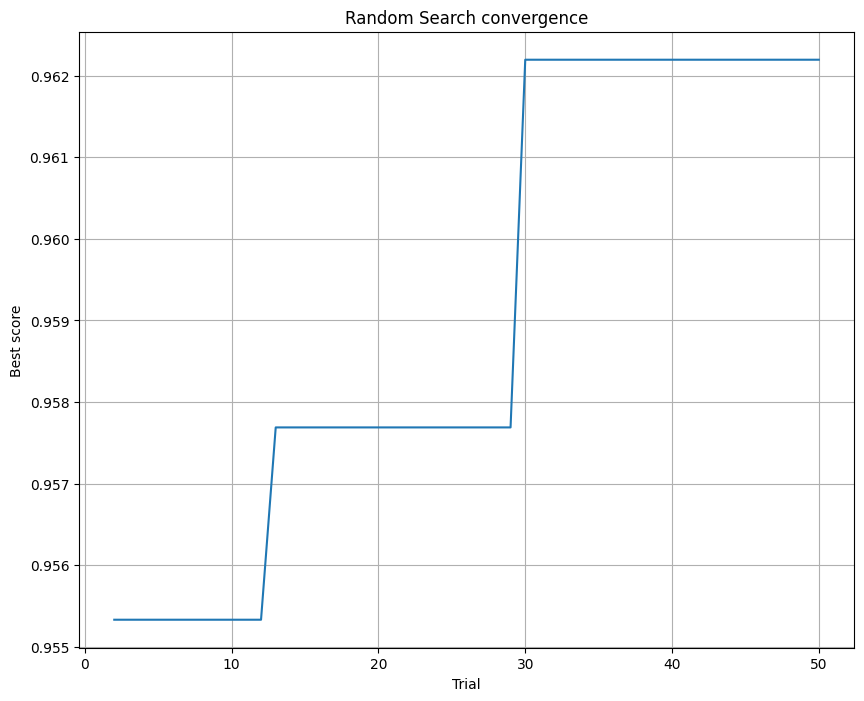

In [32]:
creating_plot('Random Search', rf_random_search.cv_results_['mean_test_score'])

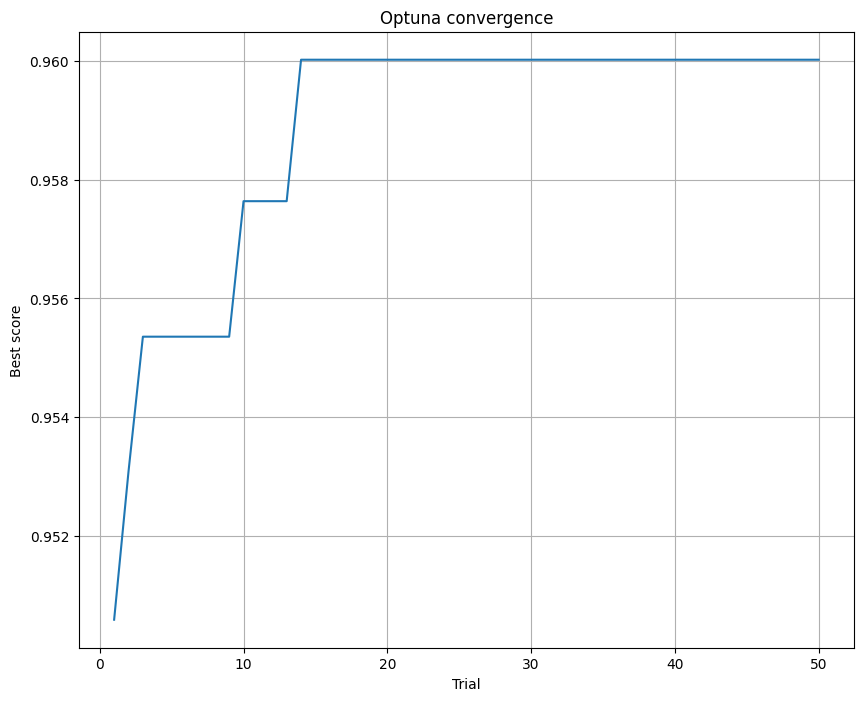

In [34]:
scores = [trial.value for trial in study.trials]
creating_plot('Optuna', scores)

Можно заметить, что optuna действительно имеет более быструю сходимость по сравнению с random search. Optuna действительно имеет мощное влияние на скорость сходимости. Сошлось в два раза почти быстрее. Однако метрики все равно не дотягивает до SVM и тем более до Logistic Regression. 